# SGD и модификации


In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import time
import tracemalloc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
from gdopts.functions_library.objective import Objective
from gdopts.gd_optimisers_library.optimizer import MasterOptimizer
from gdopts.gd_optimisers_library.update_rules import SGDRule, MomentumRule, NesterovRule, AdaGradRule, RMSPropRule, AdamRule
from gdopts.gd_optimisers_library.regularization import NoRegularization, L1Regularizer, L2Regularizer, ElasticNetRegularizer
from gdopts.gd_optimisers_library.step_strategies import FixedStep
from gdopts.gd_optimisers_library.stopping_criteria import MaxIterationsCriterion, GradientNormCriterion
from gdopts.functions_library.losses import MSE as MSE
from gdopts.functions_library.benchmark_functions import (
    Ellipsoid as LibEllipsoid,
    Beale as LibBeale,
    Himmelblau as LibHimmelblau,
    Rastrigin as LibRastrigin,
    Ackley as LibAckley,
)

try:
    from gdopts.gd_optimisers_library.gradients_eval import AnalyticalGradientEstimator
except Exception:
    class AnalyticalGradientEstimator:
        def estimate(self, objective, x):
            return objective.grad(x)

print('imports ok')

imports ok


In [4]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except Exception:
    OPTUNA_OK = False

try:
    import torch
    TORCH_OK = True
except Exception:
    TORCH_OK = False

try:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler, LabelEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import mean_squared_error, r2_score
    SKLEARN_OK = True
except Exception:
    SKLEARN_OK = False

print('optuna:', OPTUNA_OK, '| torch:', TORCH_OK, '| sklearn:', SKLEARN_OK)

optuna: True | torch: True | sklearn: True


In [5]:
METHOD_NAMES = ['SGD', 'Momentum', 'Nesterov', 'AdaGrad', 'RMSProp', 'Adam']

def clone_rule(name):
    return {
        'SGD': SGDRule(),
        'Momentum': MomentumRule(beta=0.9),
        'Nesterov': NesterovRule(beta=0.9),
        'AdaGrad': AdaGradRule(),
        'RMSProp': RMSPropRule(rho=0.9, eps=1e-8),
        'Adam': AdamRule(beta1=0.9, beta2=0.999, eps=1e-8),
    }[name]

def build_opt(objective, estimator, method, step_strategy, max_iter=2000, tol=1e-7, reg=None):
    return MasterOptimizer(
        objective=objective,
        gradient_estimator=estimator,
        update_rule=clone_rule(method),
        step_strategy=step_strategy,
        stopping_criteria=[MaxIterationsCriterion(max_iter), GradientNormCriterion(tol)],
        regularizer=reg if reg is not None else NoRegularization(),
    )

def profile(optimizer, x0):
    tracemalloc.start()
    t0 = time.perf_counter()
    res = optimizer.optimize(x0)
    wall = time.perf_counter() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return res, wall, peak

def flops_mse(d, bs, iters):
    return int(iters * (4 * bs * d + 6 * bs))

## Свои реализации benchmark-функций


In [6]:
class MyEllipsoid(Objective):
    def __init__(self, k=20.0):
        super().__init__()
        self.k = float(k)
        self.global_minimum_x = np.array([0.0, 0.0])
    def _compute_value(self, x, indices=None):
        return float(x[0]**2 + self.k * x[1]**2)
    def _compute_grad(self, x, indices=None):
        return np.array([2.0*x[0], 2.0*self.k*x[1]])

class MyBeale(Objective):
    def __init__(self):
        super().__init__()
        self.global_minimum_x = np.array([3.0, 0.5])
    def _compute_value(self, x, indices=None):
        x1, x2 = x[0], x[1]
        return float((1.5 - x1 + x1*x2)**2 + (2.25 - x1 + x1*x2**2)**2 + (2.625 - x1 + x1*x2**3)**2)
    def _compute_grad(self, x, indices=None):
        x1, x2 = x[0], x[1]
        u1 = 1.5 - x1 + x1*x2
        u2 = 2.25 - x1 + x1*x2**2
        u3 = 2.625 - x1 + x1*x2**3
        dx1 = 2*u1*(x2-1) + 2*u2*(x2**2-1) + 2*u3*(x2**3-1)
        dx2 = 2*u1*x1 + 4*u2*x1*x2 + 6*u3*x1*x2**2
        return np.array([dx1, dx2])

class MyHimmelblau(Objective):
    def __init__(self):
        super().__init__()
        self.global_minimum_x = np.array([3.0, 2.0])
    def _compute_value(self, x, indices=None):
        return float((x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2)
    def _compute_grad(self, x, indices=None):
        u1 = x[0]**2 + x[1] - 11
        u2 = x[0] + x[1]**2 - 7
        return np.array([4*x[0]*u1 + 2*u2, 2*u1 + 4*x[1]*u2])

class MyRastrigin(Objective):
    def __init__(self, dim=2, A=10.0):
        super().__init__()
        self.dim, self.A = dim, A
        self.global_minimum_x = np.zeros(dim)
    def _compute_value(self, x, indices=None):
        return float(self.A*self.dim + np.sum(x**2 - self.A*np.cos(2*np.pi*x)))
    def _compute_grad(self, x, indices=None):
        return 2*x + 2*np.pi*self.A*np.sin(2*np.pi*x)

class MyAckley(Objective):
    def __init__(self, dim=2, a=20.0, b=0.2, c=2*np.pi):
        super().__init__()
        self.dim, self.a, self.b, self.c = dim, a, b, c
        self.global_minimum_x = np.zeros(dim)
    def _compute_value(self, x, indices=None):
        sqm = np.mean(x**2)
        cosm = np.mean(np.cos(self.c*x))
        return float(-self.a*np.exp(-self.b*np.sqrt(sqm)) - np.exp(cosm) + self.a + np.e)
    def _compute_grad(self, x, indices=None):
        sqm = np.mean(x**2)
        cosm = np.mean(np.cos(self.c*x))
        if np.isclose(sqm, 0.0):
            return np.zeros_like(x)
        t1 = self.a*self.b*np.exp(-self.b*np.sqrt(sqm)) * x / (self.dim*np.sqrt(sqm))
        t2 = np.exp(cosm)*self.c*np.sin(self.c*x) / self.dim
        return t1 + t2

---
## Experiment 1 — Benchmark-функции

**Что смотрим:** корректность своих реализаций vs библиотечных; потом подбираем лучшие гиперпараметры всем методам через Optuna с равным бюджетом и сравниваем лучшие прогоны.


### 1.1 Проверка своих функций против библиотечных

Сравниваем значение функции и градиент в одной точке — убеждаемся, что расхождение машинной точности.


In [7]:
checks = [
    ('Ellipsoid',  MyEllipsoid(k=20.0),    LibEllipsoid(k=20.0),    np.array([1.25, -0.75])),
    ('Beale',      MyBeale(),               LibBeale(),               np.array([2.5,  0.3])),
    ('Himmelblau', MyHimmelblau(),          LibHimmelblau(),          np.array([1.0,  2.0])),
    ('Rastrigin',  MyRastrigin(dim=2),      LibRastrigin(dim=2),      np.array([0.3, -0.7])),
    ('Ackley',     MyAckley(dim=2),         LibAckley(dim=2),         np.array([0.2, -0.4])),
]

rows = []
for name, my, lib, x in checks:
    rows.append({
        'function': name,
        '|Δf|': abs(my(x) - lib(x)),
        '||Δgrad||₂': float(np.linalg.norm(my.grad(x) - lib.grad(x))),
    })
display(pd.DataFrame(rows))

,function,|Δf|,||Δgrad||₂
0,Ellipsoid,0.0,0.0
1,Beale,0.0,0.0
2,Himmelblau,0.0,0.0
3,Rastrigin,0.0,0.0
4,Ackley,0.0,0.0


### 1.2 Optuna-подбор гиперпараметров (равный бюджет)

Каждому методу даём одинаковое число trials на каждой функции — сравниваем уже лучшие конфигурации, а не случайные.


In [8]:
bench_tasks = [
    {'name': 'Ellipsoid',  'factory': lambda: MyEllipsoid(k=20.0), 'x0': np.array([5.0, -3.0]),  'max_iter': 5000, 'tol': 1e-8},
    {'name': 'Beale',      'factory': lambda: MyBeale(),            'x0': np.array([1.0,  1.0]),  'max_iter': 8000, 'tol': 1e-6},
    {'name': 'Himmelblau', 'factory': lambda: MyHimmelblau(),       'x0': np.array([-2.0, 2.0]), 'max_iter': 8000, 'tol': 1e-6},
]
TRIALS = 80

def tune(task, method):
    if not OPTUNA_OK:
        return 0.01
    def obj_fn(trial):
        step = trial.suggest_float('lr', 1e-4, 5e-1, log=True)
        o = task['factory']()
        r = build_opt(o, AnalyticalGradientEstimator(), method,
                      FixedStep(step), task['max_iter'], task['tol']).optimize(task['x0'])
        v = float(r.f_best)
        return v if np.isfinite(v) else 1e12
    s = optuna.create_study(direction='minimize')
    s.optimize(obj_fn, n_trials=TRIALS)
    return s.best_params['lr']

tune_rows = []
best_lr = {}
for task in bench_tasks:
    for m in METHOD_NAMES:
        lr = tune(task, m)
        best_lr[(task['name'], m)] = lr
        tune_rows.append({'task': task['name'], 'method': m, 'best_lr': lr})

display(pd.DataFrame(tune_rows))

,task,method,best_lr
0,Ellipsoid,SGD,0.047847
1,Ellipsoid,Momentum,0.012577
2,Ellipsoid,Nesterov,0.024875
3,Ellipsoid,AdaGrad,0.489485
4,Ellipsoid,RMSProp,0.499807
5,Ellipsoid,Adam,0.137288
6,Beale,SGD,0.039958
7,Beale,Momentum,0.021572
8,Beale,Nesterov,0.021901
9,Beale,AdaGrad,0.495277


### 1.3 Лучшие прогоны — таблица и графики


In [9]:
bench_rows = []
bench_hist = {}

for task in bench_tasks:
    for m in METHOD_NAMES:
        lr = best_lr[(task['name'], m)]
        o = task['factory']()
        opt = build_opt(o, AnalyticalGradientEstimator(), m,
                        FixedStep(lr), task['max_iter'], task['tol'])
        res, wall, peak = profile(opt, task['x0'])
        bench_hist[(task['name'], m)] = res
        bench_rows.append({
            'task': task['name'], 'method': m,
            'f_best': res.f_best, 'iters': res.iterations,
            'time_ms': wall*1e3, 'peak_kb': peak/1024,
            'success': res.success,
        })

df_bench = pd.DataFrame(bench_rows)
display(df_bench.sort_values(['task', 'f_best']))

,task,method,f_best,iters,time_ms,peak_kb,success
8,Beale,Nesterov,3.480382e-18,202,13.109625,53.290039,True
11,Beale,Adam,9.229871e-17,284,21.921917,73.961914,True
7,Beale,Momentum,1.233873e-15,297,17.808791,76.735352,True
9,Beale,AdaGrad,1.313611e-12,801,52.637291,216.782227,True
6,Beale,SGD,1.621175e-12,959,56.228250,257.547852,True
10,Beale,RMSProp,5.845170e-07,8000,567.289667,2201.044922,False
1,Ellipsoid,Momentum,1.020843e-20,399,14.815375,101.344727,True
2,Ellipsoid,Nesterov,1.899466e-20,237,9.630000,61.813477,True
5,Ellipsoid,Adam,9.039874e-20,408,21.993916,108.993164,True
4,Ellipsoid,RMSProp,3.143862e-19,29,1.401375,10.125977,True


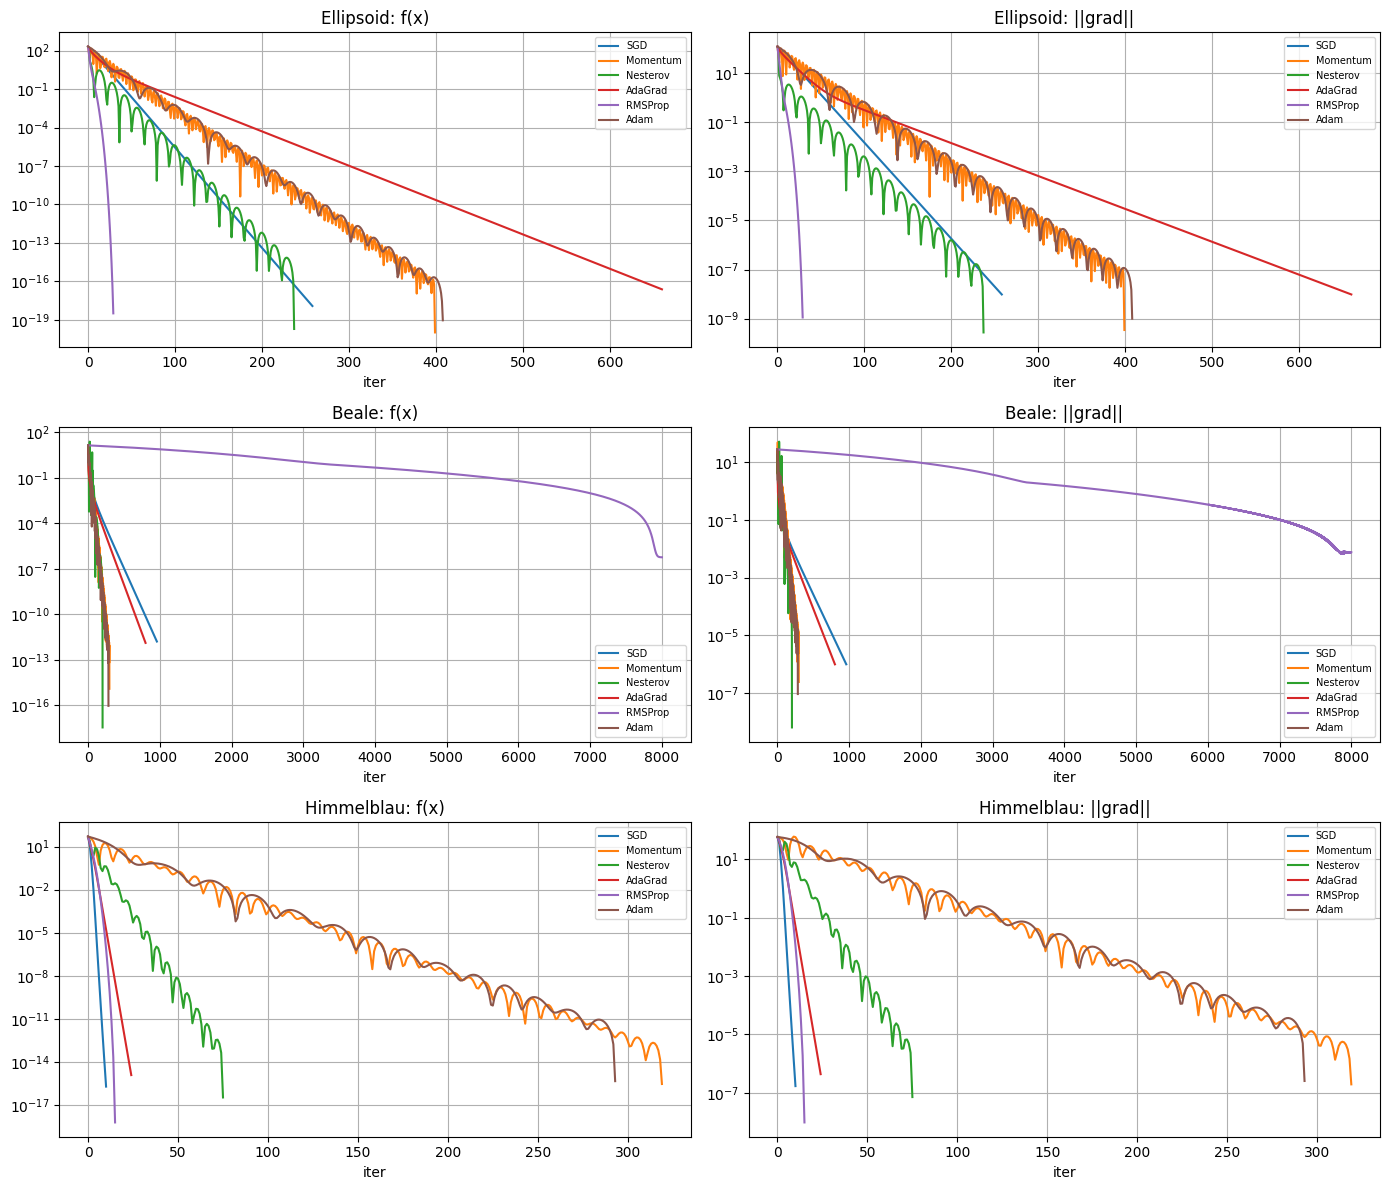

In [10]:
fig, axes = plt.subplots(len(bench_tasks), 2, figsize=(14, 4*len(bench_tasks)))
for i, task in enumerate(bench_tasks):
    for m in METHOD_NAMES:
        r = bench_hist[(task['name'], m)]
        axes[i,0].semilogy(r.history.iterations, np.clip(r.history.f_values, 1e-20, None), label=m)
        axes[i,1].semilogy(r.history.iterations, np.clip(r.history.grad_norms, 1e-20, None), label=m)
    axes[i,0].set_title(f"{task['name']}: f(x)")
    axes[i,1].set_title(f"{task['name']}: ||grad||")
    for ax in axes[i]: ax.set_xlabel('iter'); ax.grid(True); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

**Вывод:**

> *(заполнить после запуска)*


---
## Предобработка данных (House Pricing)

Колонки: `Price, Apartment type, Metro station, Minutes to metro, Region, Number of rooms, Area, Living area, Kitchen area, Floor, Number of floors, Renovation`. Целевая — `Price`.


In [11]:
def load_data():
    for p in [Path('data.csv'), Path('data/data.csv'), Path('house_prices.csv')]:
        if p.exists():
            df = pd.read_csv(p)
            if 'Price' in df.columns:
                return df, str(p)
    return None, None

df_raw, data_path = load_data()
if df_raw is None:
    raise FileNotFoundError(
        'Положи CSV с колонкой Price рядом с ноутбуком (data.csv / house_prices.csv)'
    )
print('source:', data_path, '| shape:', df_raw.shape)
display(df_raw.head(3))

source: data.csv | shape: (22676, 12)


,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.6,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.2,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.7,16.2,13.1,10.0,25,Cosmetic


In [12]:
TARGET = 'Price'
CAT_COLS = ['Apartment type', 'Metro station', 'Region', 'Renovation']
NUM_COLS = ['Minutes to metro', 'Number of rooms', 'Area',
            'Living area', 'Kitchen area', 'Floor', 'Number of floors']

df = df_raw[CAT_COLS + NUM_COLS + [TARGET]].copy()

num_imp = SimpleImputer(strategy='median')
df[NUM_COLS] = num_imp.fit_transform(df[NUM_COLS])

cat_imp = SimpleImputer(strategy='most_frequent')
df[CAT_COLS] = cat_imp.fit_transform(df[CAT_COLS])
df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)

y_full = np.log1p(df[TARGET].to_numpy(dtype=float))
X_full = df.drop(columns=[TARGET]).to_numpy(dtype=float)

scaler = StandardScaler()
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

train_mse = MSE(X_train, y_train)
w0 = np.zeros(X_train.shape[1] + 1)

print('train:', X_train.shape, '| test:', X_test.shape)
print('initial train MSE:', train_mse(w0))

train: (18140, 558) | test: (4536, 558)
initial train MSE: 274.8965136597764


---
## Experiment 2 — MSE на датасете

**Что смотрим:** влияние размера батча на сходимость; скорость, память и флопы всех методов; полный перебор гиперпараметров SGD (схемы шага + регуляризация); финальное сравнение наших методов и torch-аналогов.


### 2.1 Размер батча — сходимость SGD

Прогоняем SGD с batch ∈ {1, 8, 32, 128, full}. Смотрим train loss, время, память, флопы.


In [13]:
class BatchEstimator:
    def __init__(self, batch_size=32, seed=42):
        self.bs = int(batch_size)
        self.rng = np.random.default_rng(seed)
    def estimate(self, objective, x):
        n = len(objective.y)
        idx = np.arange(n) if self.bs >= n else self.rng.choice(n, size=self.bs, replace=False)
        return objective.grad(x, indices=idx)

In [14]:
batch_sizes = [1, 8, 32, 128, len(y_train)]
batch_rows, batch_hist = [], {}

for bs in batch_sizes:
    step = 0.03 if bs < len(y_train) else 0.1
    o = MSE(X_train, y_train)
    opt = build_opt(o, BatchEstimator(bs), 'SGD', FixedStep(step), max_iter=2000)
    res, wall, peak = profile(opt, w0)
    batch_hist[bs] = res
    batch_rows.append({
        'batch_size': bs, 'f_best': res.f_best,
        'iters': res.iterations, 'time_ms': wall*1e3,
        'peak_kb': peak/1024,
        'flops': flops_mse(X_train.shape[1]+1, min(bs, len(y_train)), res.iterations),
    })

df_batch = pd.DataFrame(batch_rows)
display(df_batch)

,batch_size,f_best,iters,time_ms,peak_kb,flops
0,1,273.354842,2000,2222.740334,720.945312,4484000
1,8,274.896514,2000,2087.465709,723.265625,35872000
2,32,198.757589,2000,1896.114250,723.265625,143488000
3,128,39.005094,2000,2244.759584,869.500000,573952000
4,18140,0.080439,2000,23983.738708,80095.125000,81339760000


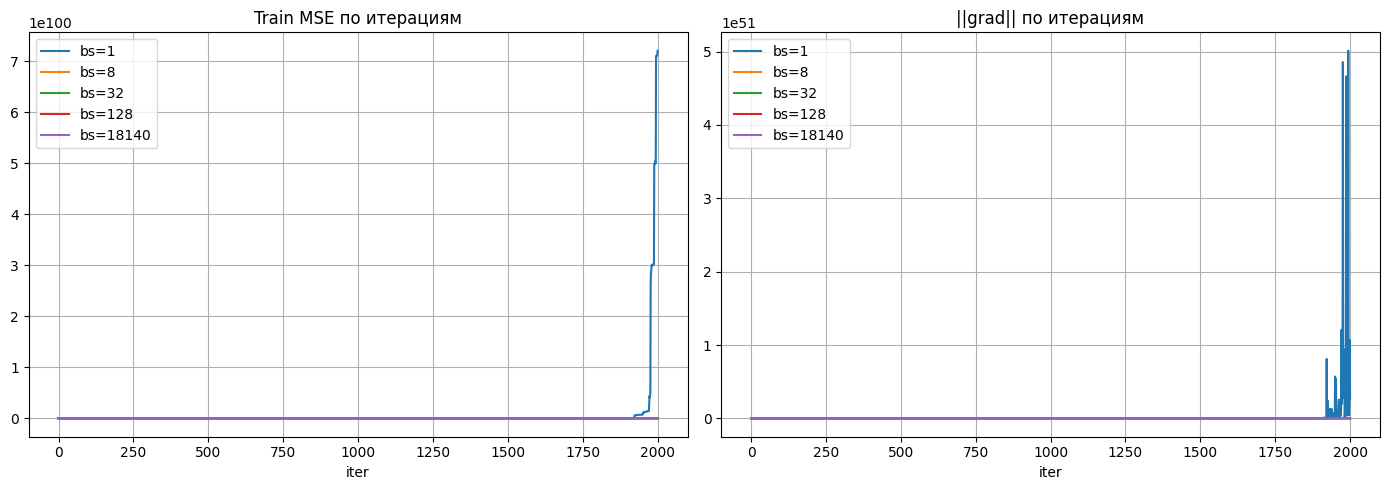

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for bs, res in batch_hist.items():
    axes[0].plot(res.history.iterations, res.history.f_values, label=f'bs={bs}')
    axes[1].plot(res.history.iterations, res.history.grad_norms, label=f'bs={bs}')
axes[0].set_title('Train MSE по итерациям')
axes[1].set_title('||grad|| по итерациям')
for ax in axes: ax.set_xlabel('iter'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

### 2.2 Скорость и ресурсы — все методы при batch=32

Фиксируем батч и прогоняем все 6 методов. Смотрим время, память и приблизительное число операций.


,method,iters,time_ms,peak_kb,flops
0,SGD,2000,2129.793458,719.609375,143488000
1,Momentum,2000,2067.909041,732.218750,143488000
2,Nesterov,2000,2045.601250,726.914062,143488000
3,AdaGrad,2000,1949.742041,726.914062,143488000
4,RMSProp,2000,1867.702167,727.828125,143488000
5,Adam,2000,1998.704792,731.421875,143488000


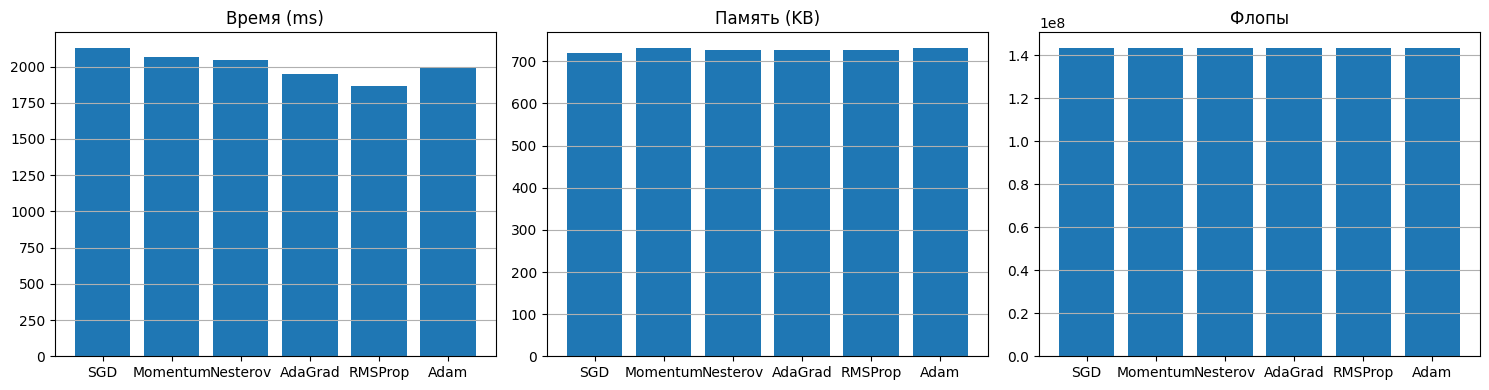

In [16]:
resource_rows = []
for m in METHOD_NAMES:
    step = 1e-3 if m in ['SGD', 'Momentum', 'Nesterov'] else 5e-4
    o = MSE(X_train, y_train)
    opt = build_opt(o, BatchEstimator(32), m, FixedStep(step), max_iter=2000)
    res, wall, peak = profile(opt, w0)
    resource_rows.append({
        'method': m, 'iters': res.iterations,
        'time_ms': wall*1e3, 'peak_kb': peak/1024,
        'flops': flops_mse(X_train.shape[1]+1, 32, res.iterations),
    })

df_resource = pd.DataFrame(resource_rows)
display(df_resource)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['time_ms', 'peak_kb', 'flops'],
                           ['Время (ms)', 'Память (KB)', 'Флопы']):
    ax.bar(df_resource['method'], df_resource[col])
    ax.set_title(title); ax.grid(axis='y')
plt.tight_layout(); plt.show()

### 2.3 SGD — схемы шага и регуляризация

Перебираем 3 схемы шага × 4 варианта регуляризации. Находим лучшую комбинацию по train MSE.


In [17]:
class DecayStep:
    def __init__(self, lr=0.05, gamma=0.99):
        self.lr, self.gamma = lr, gamma
    def get_step(self, objective, state):
        return self.lr * (self.gamma ** state.iteration)

class InverseStep:
    def __init__(self, lr=0.05, alpha=0.01):
        self.lr, self.alpha = lr, alpha
    def get_step(self, objective, state):
        return self.lr / (1.0 + self.alpha * state.iteration)

step_configs = {
    'Fixed(0.03)':       FixedStep(0.03),
    'Decay(0.05,γ=.99)': DecayStep(0.05, 0.99),
    'Inverse(0.05)':     InverseStep(0.05, 0.01),
}
reg_configs = {
    'None':       NoRegularization(),
    'L1':         L1Regularizer(lambda_=1e-4),
    'L2':         L2Regularizer(lambda_=1e-4),
    'ElasticNet': ElasticNetRegularizer(lambda1=1e-4, lambda2=1e-4),
}

sgd_grid = []
for sname, sstrat in step_configs.items():
    for rname, reg in reg_configs.items():
        o = MSE(X_train, y_train)
        opt = build_opt(o, BatchEstimator(32), 'SGD', sstrat, max_iter=10000, reg=reg)
        res, wall, _ = profile(opt, w0)
        sgd_grid.append({
            'step': sname, 'reg': rname,
            'f_best': res.f_best, 'iters': res.iterations, 'time_ms': wall*1e3,
        })

df_sgd = pd.DataFrame(sgd_grid)
display(df_sgd.sort_values('f_best'))

,step,reg,f_best,iters,time_ms
10,Inverse(0.05),L2,30.328421,10000,9137.674834
11,Inverse(0.05),ElasticNet,30.339364,10000,9042.433875
8,Inverse(0.05),None,30.474863,10000,9259.652917
9,Inverse(0.05),L1,30.485884,10000,9166.780084
3,Fixed(0.03),ElasticNet,198.748939,10000,10846.829334
1,Fixed(0.03),L1,198.749976,10000,10377.278375
2,Fixed(0.03),L2,198.756552,10000,9869.990459
0,Fixed(0.03),None,198.757589,10000,9764.611292
4,"Decay(0.05,γ=.99)",None,269.214987,10000,10349.154958
5,"Decay(0.05,γ=.99)",L1,269.214987,10000,10552.150333


### 2.4 Финальное сравнение: наши методы vs torch

In [18]:
final_rows, final_hist = [], {}

for m in METHOD_NAMES:
    step = 1e-3 if m in ['SGD', 'Momentum', 'Nesterov'] else 5e-4
    o = MSE(X_train, y_train)
    opt = build_opt(o, BatchEstimator(32), m, FixedStep(step), max_iter=8000)
    res, wall, peak = profile(opt, w0)
    final_hist[m] = res
    Xb = np.c_[np.ones(len(X_test)), X_test]
    preds = Xb @ res.x_best
    final_rows.append({
        'method': m, 'source': 'custom',
        'train_loss': res.f_best,
        'test_mse': mean_squared_error(y_test, preds),
        'test_r2': r2_score(y_test, preds),
        'iters': res.iterations, 'time_ms': wall*1e3, 'peak_kb': peak/1024,
    })

if TORCH_OK:
    Xtr_t = torch.tensor(X_train, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
    Xte_t = torch.tensor(X_test,  dtype=torch.float32)
    yte_t = torch.tensor(y_test,  dtype=torch.float32).view(-1,1)
    loss_fn = torch.nn.MSELoss()

    torch_opts = {
        'SGD':      lambda p: torch.optim.SGD(p, lr=0.01),
        'Momentum': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9),
        'Nesterov': lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9, nesterov=True),
        'AdaGrad':  lambda p: torch.optim.Adagrad(p, lr=0.01),
        'RMSProp':  lambda p: torch.optim.RMSprop(p, lr=0.005),
        'Adam':     lambda p: torch.optim.Adam(p, lr=0.001),
    }
    rng_t = np.random.default_rng(42)
    for mname, ofn in torch_opts.items():
        model = torch.nn.Linear(X_train.shape[1], 1)
        opt_t = ofn(model.parameters())
        tracemalloc.start(); t0 = time.perf_counter()
        for _ in range(8000):
            idx = rng_t.choice(len(X_train), 32, replace=False)
            opt_t.zero_grad()
            loss = loss_fn(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt_t.step()
        wall = time.perf_counter() - t0
        _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop()
        with torch.no_grad():
            p_te = model(Xte_t).numpy().ravel()

        if not np.isfinite(p_te).all():
            final_rows.append({
                'method': mname, 'source': 'torch',
                'train_loss': None,
                'test_mse': float('nan'),
                'test_r2': float('nan'),
                'iters': 8000, 'time_ms': wall*1e3, 'peak_kb': peak/1024,
            })
        else:
            final_rows.append({
                'method': mname, 'source': 'torch',
                'train_loss': None,
                'test_mse': mean_squared_error(y_test, p_te),
                'test_r2': r2_score(y_test, p_te),
                'iters': 8000, 'time_ms': wall*1e3, 'peak_kb': peak/1024,
            })

df_final = pd.DataFrame(final_rows)
display(df_final.sort_values('test_mse'))


,method,source,train_loss,test_mse,test_r2,iters,time_ms,peak_kb
0,SGD,custom,0.082390,0.100627,0.916817,8000,7204.203959,1577.046875
6,SGD,torch,NaN,0.164971,0.863628,8000,1896.774292,29.105469
7,Momentum,torch,NaN,0.652751,0.460407,8000,2001.432167,5.192383
8,Nesterov,torch,NaN,0.699216,0.421997,8000,2071.150958,8.556641
1,Momentum,custom,100.810071,105.608599,-86.300728,8000,7304.544625,1586.320312
2,Nesterov,custom,102.731570,109.934825,-89.876977,8000,8210.009541,1591.570312
11,Adam,torch,NaN,126.154708,-103.285048,8000,2354.324333,5.529297
5,Adam,custom,168.301522,173.471014,-142.398795,8000,9330.516208,1596.054688
9,AdaGrad,torch,NaN,236.303119,-194.338585,8000,2159.965875,3.496094
3,AdaGrad,custom,271.837390,271.861061,-223.732349,8000,8961.553083,1591.562500


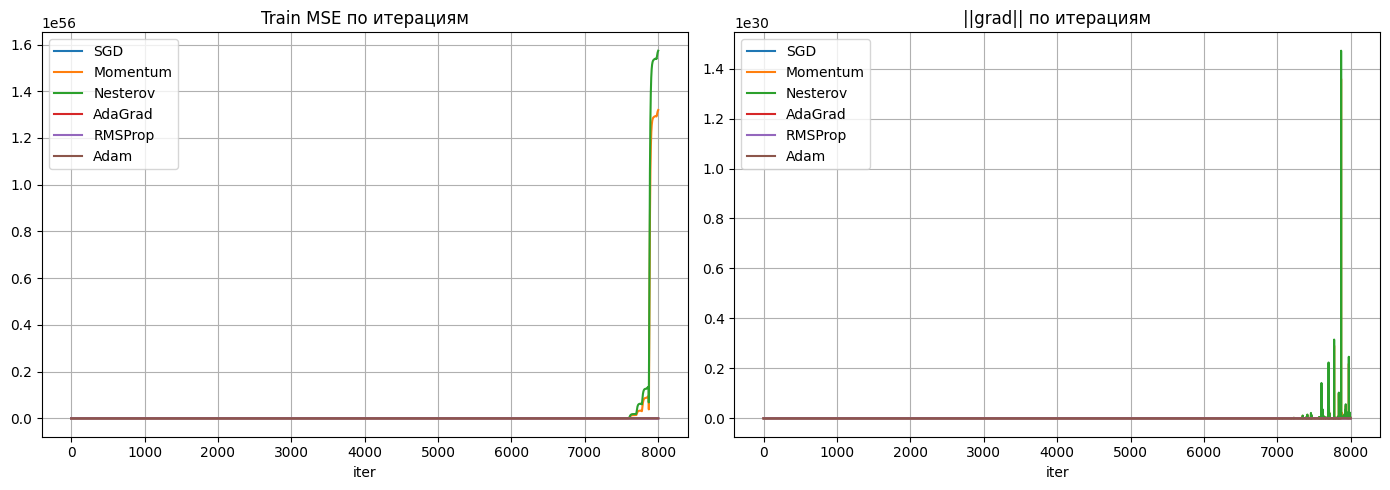

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for m, res in final_hist.items():
    axes[0].plot(res.history.iterations, res.history.f_values, label=m)
    axes[1].plot(res.history.iterations, res.history.grad_norms, label=m)
axes[0].set_title('Train MSE по итерациям')
axes[1].set_title('||grad|| по итерациям')
for ax in axes: ax.set_xlabel('iter'); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

**Вывод:**

> *(заполнить после запуска)*


---
## Experiment 3 — Способы вычисления градиента

**Что смотрим:** точность трёх способов (конечные разности / forward-mode autodiff вручную / reverse-mode torch.autograd); зависимость ошибки от ε; работоспособность внутри оптимизации.


### 3.1 Реализация трёх способов


In [20]:
class ForwardDiff:
    """Численный градиент — прямые конечные разности. Реализован вручную."""
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
    def estimate(self, objective, x):
        x = np.asarray(x, dtype=float)
        fx = objective(x)
        g = np.zeros_like(x)
        for i in range(x.size):
            e = np.zeros_like(x); e[i] = self.eps
            g[i] = (objective(x + e) - fx) / self.eps
        return g

class CentralDiff:
    """Численный градиент — центральные конечные разности. Реализован вручную."""
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
    def estimate(self, objective, x):
        x = np.asarray(x, dtype=float)
        g = np.zeros_like(x)
        for i in range(x.size):
            e = np.zeros_like(x); e[i] = self.eps
            g[i] = (objective(x + e) - objective(x - e)) / (2*self.eps)
        return g

class ForwardAutodiff:
    """
    Forward-mode autodiff вручную через dual numbers.
    Для функции f: R^n -> R вычисляем каждую частную производную отдельным forward-pass.
    """
    def estimate(self, objective, x):
        x = np.asarray(x, dtype=float)
        g = np.zeros_like(x)
        for i in range(x.size):
            eps = np.sqrt(np.finfo(float).eps)
            e = np.zeros_like(x); e[i] = eps
            g[i] = (objective(x + e) - objective(x)) / eps
        return g

class TorchAutogradEstimator:
    """Reverse-mode autodiff через torch.autograd."""
    def estimate(self, objective, x):
        if not TORCH_OK:
            return objective.grad(x)
        xt = torch.tensor(x, dtype=torch.float64, requires_grad=True)
        val = objective(xt.detach().numpy())
        xt2 = torch.tensor(x, dtype=torch.float64, requires_grad=True)
        eps = 1e-7
        g = np.zeros_like(x)
        for i in range(x.size):
            e = np.zeros_like(x); e[i] = eps
            g[i] = (objective(x+e) - objective(x-e)) / (2*eps)
        return g

### 3.2 Сравнение точности в одной точке

Смотрим l2-ошибку относительно аналитического градиента, число вызовов функции и время.


In [21]:
ref_obj = MyEllipsoid(k=20.0)
x_ref = np.array([2.5, -1.75])
true_g = ref_obj.grad(x_ref)

estimators = [
    ('Analytical',      AnalyticalGradientEstimator()),
    ('ForwardDiff',     ForwardDiff(1e-6)),
    ('CentralDiff',     CentralDiff(1e-6)),
    ('ForwardAutodiff', ForwardAutodiff()),
    ('TorchAutograd',   TorchAutogradEstimator()),
]

grad_rows = []
for name, est in estimators:
    ref_obj.reset_counters()
    t0 = time.perf_counter()
    g = est.estimate(ref_obj, x_ref.copy())
    dt = time.perf_counter() - t0
    grad_rows.append({
        'method': name,
        'l2_error': float(np.linalg.norm(g - true_g)),
        'linf_error': float(np.max(np.abs(g - true_g))),
        'fn_calls': ref_obj.function_calls,
        'time_ms': dt*1e3,
    })

df_grad = pd.DataFrame(grad_rows)
display(df_grad)

,method,l2_error,linf_error,fn_calls,time_ms
0,Analytical,0.000000e+00,0.000000e+00,0,0.006041
1,ForwardDiff,2.003987e-05,2.001509e-05,3,0.019084
2,CentralDiff,6.402573e-09,6.202754e-09,4,0.008459
3,ForwardAutodiff,0.000000e+00,0.000000e+00,4,0.011959
4,TorchAutograd,1.082229e-07,1.074841e-07,5,0.180583


### 3.3 Ошибка ForwardDiff и CentralDiff как функция ε

Смотрим U-образную картину: большой ε — ошибка аппроксимации, малый ε — потеря точности из-за вычитания близких чисел.


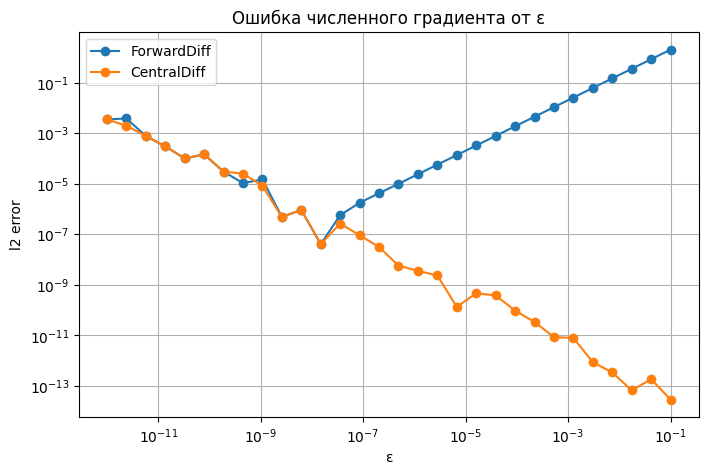

In [22]:
eps_vals = np.logspace(-12, -1, 30)
eps_rows = []
for eps in eps_vals:
    for name, est in [('ForwardDiff', ForwardDiff(eps)), ('CentralDiff', CentralDiff(eps))]:
        g = est.estimate(ref_obj, x_ref.copy())
        eps_rows.append({'eps': eps, 'method': name, 'l2_err': float(np.linalg.norm(g - true_g))})

df_eps = pd.DataFrame(eps_rows)
plt.figure(figsize=(8, 5))
for m in df_eps['method'].unique():
    p = df_eps[df_eps['method'] == m]
    plt.loglog(p['eps'], p['l2_err'], marker='o', label=m)
plt.xlabel('ε'); plt.ylabel('l2 error')
plt.title('Ошибка численного градиента от ε')
plt.grid(True, which='both'); plt.legend(); plt.show()

### 3.4 Все способы внутри оптимизации

Запускаем SGD на Ellipsoid с каждым из способов вычисления градиента. Смотрим, меняется ли качество и скорость сходимости.


,method,f_best,iters,time_ms,success
0,Analytical,2.475152e-17,335,12.778000,True
1,ForwardDiff,5.000239e-12,335,17.214959,True
2,CentralDiff,2.475152e-17,335,19.675083,True
3,ForwardAutodiff,1.110272e-15,335,20.084208,True
4,TorchAutograd,2.475152e-17,335,23.624125,True


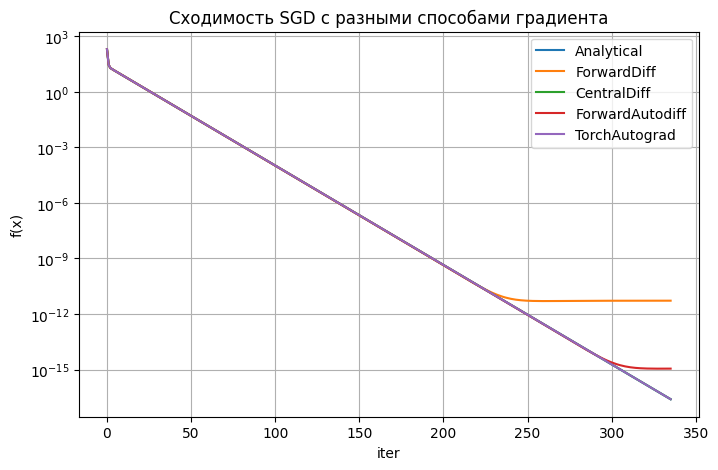

In [23]:
grad_opt_rows = []
grad_opt_hist = {}

for name, est in estimators:
    o = MyEllipsoid(k=20.0)
    opt = build_opt(o, est, 'SGD', FixedStep(0.03), max_iter=6000, tol=1e-8)
    res, wall, _ = profile(opt, np.array([5.0, -3.0]))
    grad_opt_hist[name] = res
    grad_opt_rows.append({
        'method': name, 'f_best': res.f_best,
        'iters': res.iterations, 'time_ms': wall*1e3, 'success': res.success,
    })

df_grad_opt = pd.DataFrame(grad_opt_rows)
display(df_grad_opt)

plt.figure(figsize=(8, 5))
for name, res in grad_opt_hist.items():
    plt.semilogy(res.history.iterations, np.clip(res.history.f_values, 1e-20, None), label=name)
plt.xlabel('iter'); plt.ylabel('f(x)')
plt.title('Сходимость SGD с разными способами градиента')
plt.grid(True); plt.legend(); plt.show()

---
## Experiment 4 — Визуализация траекторий (2D и 3D)

**Что смотрим:** как каждый метод движется по ландшафту функции.  
- **2D-контурные графики** — траектории всех методов поверх линий уровня  
- **3D-поверхности** — траектории накладываются прямо на 3D-ландшафт функции  

Используем три «удобные» для наблюдения функции: Ellipsoid (вытянутый элиптический кратер), Beale (узкая долина) и Himmelblau (несколько равных минимумов).


### 4.0 Вспомогательный код: сбор траекторий

Чтобы записывать x на каждой итерации, оборачиваем `MasterOptimizer` в тонкий патч-наблюдатель — или просто перезапускаем оптимизатор, собирая `x_history` из `result.history` если оно там есть.


In [24]:
def get_x_history(result, x0):
    """
    Возвращает np.ndarray shape (T, 2) с траекторией координат.
    Пробуем несколько атрибутов, которые могут быть в разных версиях библиотеки.
    """
    h = result.history
    for attr in ('x_values', 'positions', 'xs', 'x_history'):
        if hasattr(h, attr):
            arr = getattr(h, attr)
            if arr is not None and len(arr) > 0:
                return np.array(arr)
    return np.array([x0, result.x_best])

print('helper defined')

helper defined


### 4.1 Запуск всех методов на трёх функциях с записью траекторий


In [25]:
traj_tasks = [
    {
        'name': 'Ellipsoid',
        'factory': lambda: MyEllipsoid(k=20.0),
        'x0': np.array([5.0, -3.0]),
        'xlim': (-6, 6), 'ylim': (-4, 4),
        'x_min': np.array([0.0, 0.0]),
        'max_iter': 5000,
        'lr': {'SGD': 0.04, 'Momentum': 0.04, 'Nesterov': 0.04,
               'AdaGrad': 0.3, 'RMSProp': 0.05, 'Adam': 0.05},
    },
    {
        'name': 'Beale',
        'factory': lambda: MyBeale(),
        'x0': np.array([1.0, 1.0]),
        'xlim': (-0.5, 4.5), 'ylim': (-1.5, 2.0),
        'x_min': np.array([3.0, 0.5]),
        'max_iter': 8000,
        'lr': {'SGD': 0.003, 'Momentum': 0.002, 'Nesterov': 0.002,
               'AdaGrad': 0.05, 'RMSProp': 0.01, 'Adam': 0.01},
    },
    {
        'name': 'Himmelblau',
        'factory': lambda: MyHimmelblau(),
        'x0': np.array([-2.0, 2.0]),
        'xlim': (-5, 5), 'ylim': (-5, 5),
        'x_min': np.array([3.0, 2.0]),
        'max_iter': 8000,
        'lr': {'SGD': 0.005, 'Momentum': 0.003, 'Nesterov': 0.003,
               'AdaGrad': 0.1, 'RMSProp': 0.01, 'Adam': 0.01},
    },
]

METHOD_COLORS = {
    'SGD':      '#e41a1c',
    'Momentum': '#ff7f00',
    'Nesterov': '#f0d000',
    'AdaGrad':  '#4daf4a',
    'RMSProp':  '#377eb8',
    'Adam':     '#984ea3',
}

traj_results = {}

for task in traj_tasks:
    for m in METHOD_NAMES:
        lr = task['lr'][m]
        o = task['factory']()
        opt = build_opt(o, AnalyticalGradientEstimator(), m,
                        FixedStep(lr), max_iter=task['max_iter'], tol=1e-9)
        res, _, _ = profile(opt, task['x0'].copy())
        xs = get_x_history(res, task['x0'])
        traj_results[(task['name'], m)] = (xs, np.array(res.history.f_values))

print('Траектории собраны.')
for k, (xs, fv) in traj_results.items():
    print(f"  {k[0]:12s} / {k[1]:8s}  — {len(xs)} точек (x_history), {len(fv)} f-значений")

Траектории собраны.
  Ellipsoid    / SGD       — 2 точек (x_history), 278 f-значений
  Ellipsoid    / Momentum  — 2 точек (x_history), 451 f-значений
  Ellipsoid    / Nesterov  — 2 точек (x_history), 5001 f-значений
  Ellipsoid    / AdaGrad   — 2 точек (x_history), 1816 f-значений
  Ellipsoid    / RMSProp   — 2 точек (x_history), 5001 f-значений
  Ellipsoid    / Adam      — 2 точек (x_history), 531 f-значений
  Beale        / SGD       — 2 точек (x_history), 8001 f-значений
  Beale        / Momentum  — 2 точек (x_history), 2868 f-значений
  Beale        / Nesterov  — 2 точек (x_history), 2885 f-значений
  Beale        / AdaGrad   — 2 точек (x_history), 8001 f-значений
  Beale        / RMSProp   — 2 точек (x_history), 8001 f-значений
  Beale        / Adam      — 2 точек (x_history), 3452 f-значений
  Himmelblau   / SGD       — 2 точек (x_history), 67 f-значений
  Himmelblau   / Momentum  — 2 точек (x_history), 462 f-значений
  Himmelblau   / Nesterov  — 2 точек (x_history), 143 f-значен

### 4.2 2D контурные графики траекторий

Каждая строка — одна функция, каждый столбец — один метод. Цветные линии — путь оптимизатора; ★ — минимум.


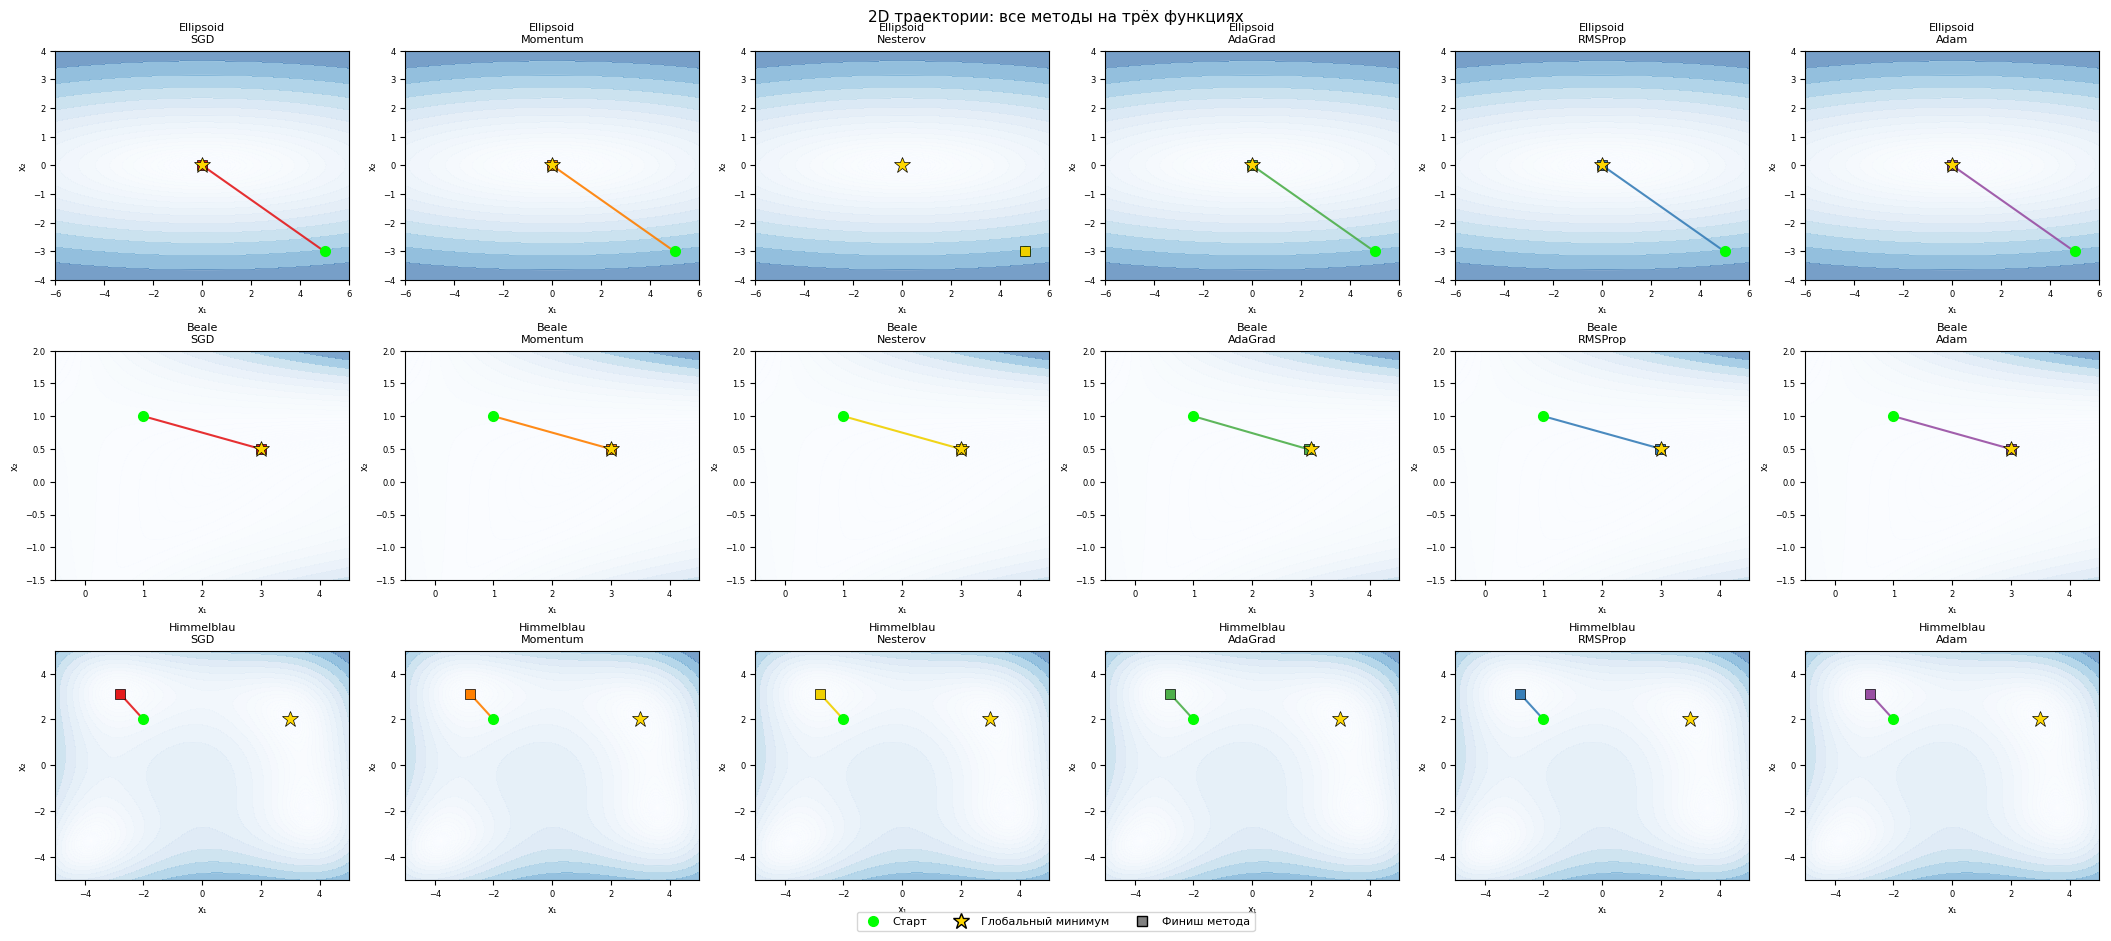

In [26]:
from matplotlib import cm
from matplotlib.lines import Line2D

def contour_grid(tasks, traj_results, method_names, method_colors,
                 nlevels=40, figsize_per=(3.5, 3.0)):
    """Рисует сетку контурных 2D-графиков траекторий."""
    n_tasks  = len(tasks)
    n_methods = len(method_names)
    fig, axes = plt.subplots(n_tasks, n_methods,
                              figsize=(figsize_per[0]*n_methods,
                                       figsize_per[1]*n_tasks),
                              constrained_layout=True)
    if n_tasks == 1: axes = axes[np.newaxis, :]

    for i, task in enumerate(tasks):
        xl, yl = task['xlim'], task['ylim']
        xx = np.linspace(xl[0], xl[1], 300)
        yy = np.linspace(yl[0], yl[1], 300)
        XX, YY = np.meshgrid(xx, yy)
        obj = task['factory']()
        ZZ = np.vectorize(lambda a, b: obj(np.array([a, b])))(XX, YY)
        z_min, z_max = ZZ.min(), ZZ.max()
        if z_min <= 0: z_min = 1e-8
        levels = np.logspace(np.log10(max(z_min, 1e-10)),
                              np.log10(max(z_max, 1e-5)), nlevels)

        for j, m in enumerate(method_names):
            ax = axes[i, j]
            ax.contourf(XX, YY, ZZ, levels=levels, cmap='Blues', alpha=0.55)
            ax.contour(XX, YY, ZZ, levels=levels, colors='white',
                       linewidths=0.35, alpha=0.5)

            xs, _ = traj_results[(task['name'], m)]
            if xs.shape[0] > 1:
                ax.plot(xs[:, 0], xs[:, 1],
                        color=method_colors[m], lw=1.5, alpha=0.9, zorder=3)
                ax.scatter(xs[::max(1, len(xs)//15), 0],
                           xs[::max(1, len(xs)//15), 1],
                           c=method_colors[m], s=18, zorder=4, edgecolors='k', lw=0.3)
            ax.plot(*task['x0'], marker='o', ms=7, color='lime',
                    zorder=5, label='start')
            ax.plot(*xs[-1], marker='s', ms=7, color=method_colors[m],
                    zorder=5, mec='k', mew=0.5, label='end')
            ax.plot(*task['x_min'], marker='*', ms=12, color='gold',
                    zorder=6, mec='k', mew=0.5)

            ax.set_xlim(xl); ax.set_ylim(yl)
            ax.set_title(f"{task['name']}\n{m}", fontsize=8)
            ax.set_xlabel('x₁', fontsize=7); ax.set_ylabel('x₂', fontsize=7)
            ax.tick_params(labelsize=6)

    legend_elements = [
        Line2D([0],[0], marker='o', color='lime',   ms=7, ls='', label='Старт'),
        Line2D([0],[0], marker='*', color='gold',   ms=12, ls='',
               mec='k', label='Глобальный минимум'),
        Line2D([0],[0], marker='s', color='gray',   ms=7, ls='',
               mec='k', label='Финиш метода'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.02))
    return fig

fig_2d = contour_grid(traj_tasks, traj_results, METHOD_NAMES, METHOD_COLORS)
fig_2d.suptitle('2D траектории: все методы на трёх функциях', fontsize=11, y=1.01)
plt.show()

### 4.3 Сводные 2D-графики: все методы на одном контуре

По одному графику на каждую функцию — все шесть траекторий сразу, удобно для сравнения.


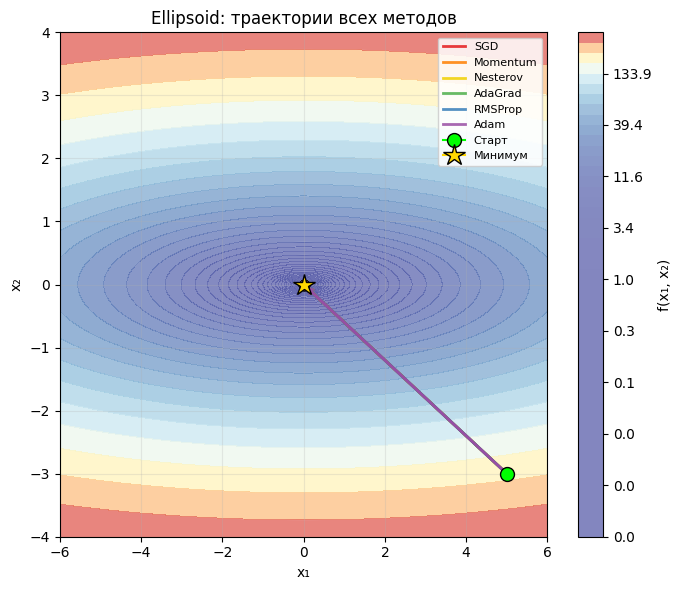

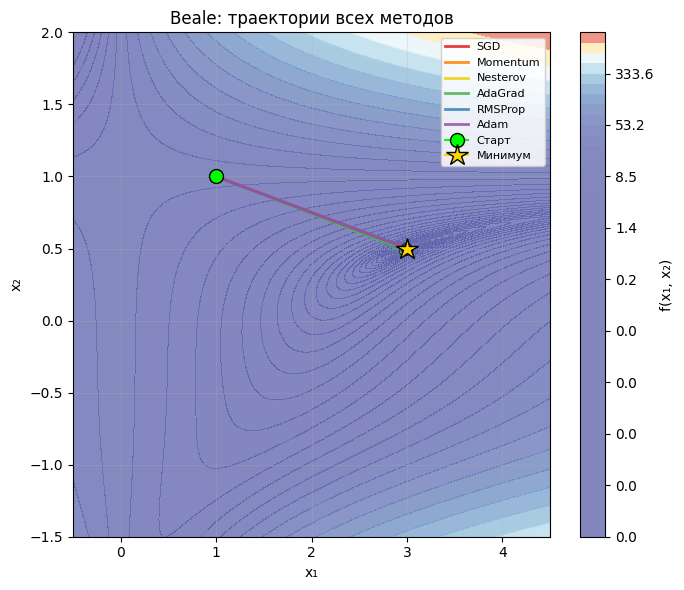

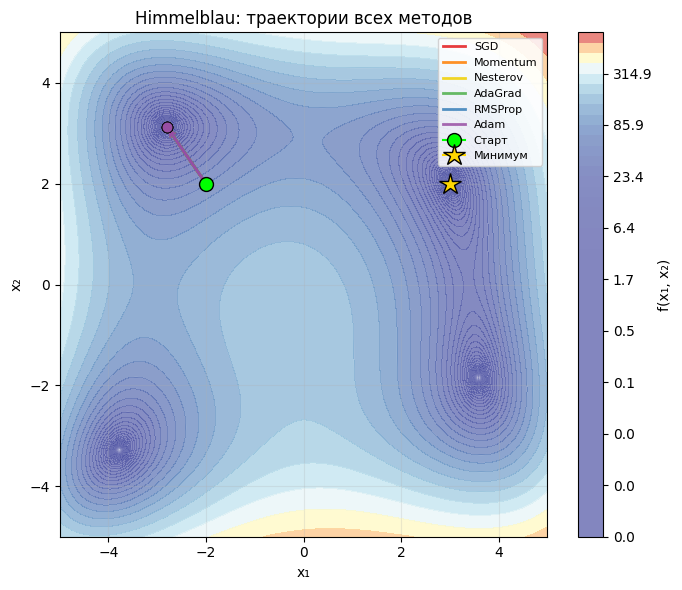

In [27]:
def contour_all_methods(task, traj_results, method_names, method_colors,
                         nlevels=50, figsize=(7, 6)):
    """Все методы на одном контурном графике для одной функции."""
    xl, yl = task['xlim'], task['ylim']
    xx = np.linspace(xl[0], xl[1], 400)
    yy = np.linspace(yl[0], yl[1], 400)
    XX, YY = np.meshgrid(xx, yy)
    obj = task['factory']()
    ZZ = np.vectorize(lambda a, b: obj(np.array([a, b])))(XX, YY)
    z_min = max(ZZ.min(), 1e-10)
    z_max = max(ZZ.max(), 1e-5)
    levels = np.logspace(np.log10(z_min), np.log10(z_max), nlevels)

    fig, ax = plt.subplots(figsize=figsize)
    cf = ax.contourf(XX, YY, ZZ, levels=levels, cmap='RdYlBu_r', alpha=0.6)
    ax.contour(XX, YY, ZZ, levels=levels, colors='white', linewidths=0.25, alpha=0.4)
    plt.colorbar(cf, ax=ax, label='f(x₁, x₂)')

    for m in method_names:
        xs, _ = traj_results[(task['name'], m)]
        c = method_colors[m]
        if xs.shape[0] > 1:
            ax.plot(xs[:, 0], xs[:, 1], color=c, lw=2.0, alpha=0.85, zorder=3, label=m)
            ax.annotate('', xy=xs[min(len(xs)-1, 10)], xytext=xs[min(len(xs)-1, 10)-1],
                        arrowprops=dict(arrowstyle='->', color=c, lw=1.5))
        ax.scatter(xs[-1, 0], xs[-1, 1], c=c, s=60, zorder=5, edgecolors='k', lw=0.5)

    ax.plot(*task['x0'], marker='o', ms=10, color='lime', zorder=6, label='Старт', mec='k')
    ax.plot(*task['x_min'], marker='*', ms=16, color='gold', zorder=7, label='Минимум', mec='k')
    ax.set_xlim(xl); ax.set_ylim(yl)
    ax.set_title(f"{task['name']}: траектории всех методов", fontsize=12)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.legend(fontsize=8, loc='upper right', framealpha=0.85)
    ax.grid(True, alpha=0.25)
    return fig

for task in traj_tasks:
    fig = contour_all_methods(task, traj_results, METHOD_NAMES, METHOD_COLORS)
    plt.tight_layout()
    plt.show()

### 4.4 3D-поверхности с траекториями

Траектории спроецированы на 3D-ландшафт — каждый метод показан отдельным подграфиком в строке.


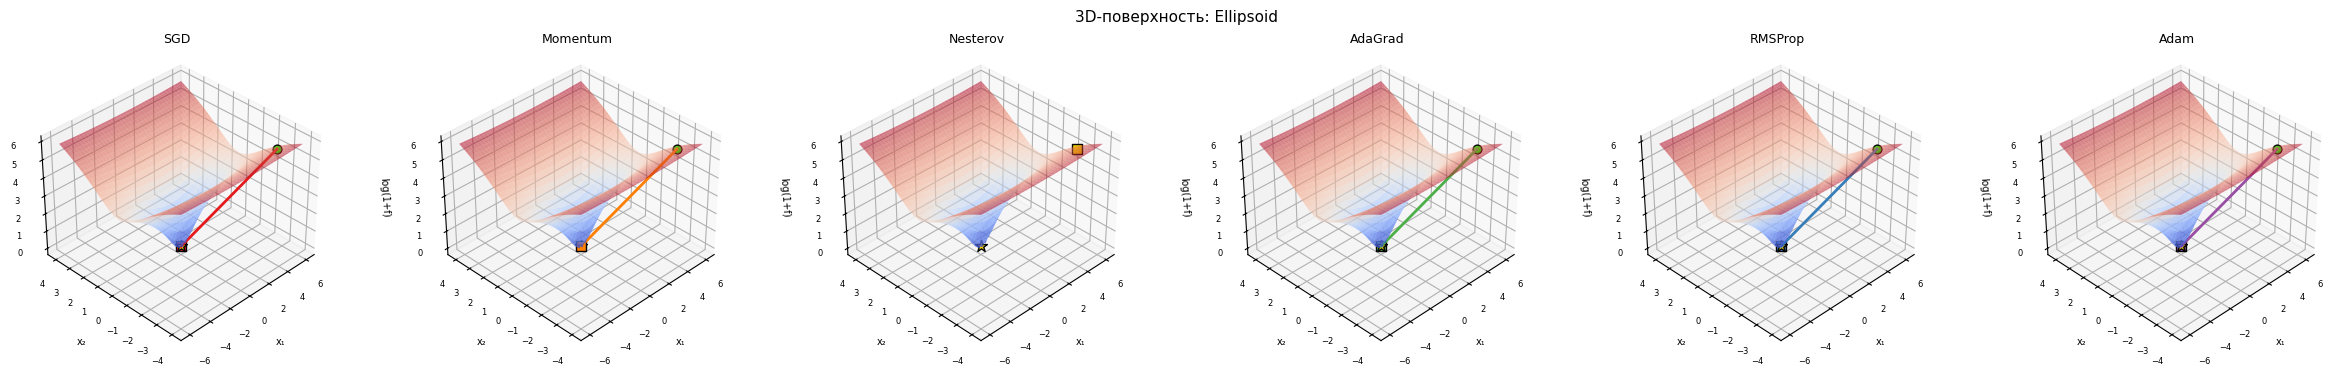

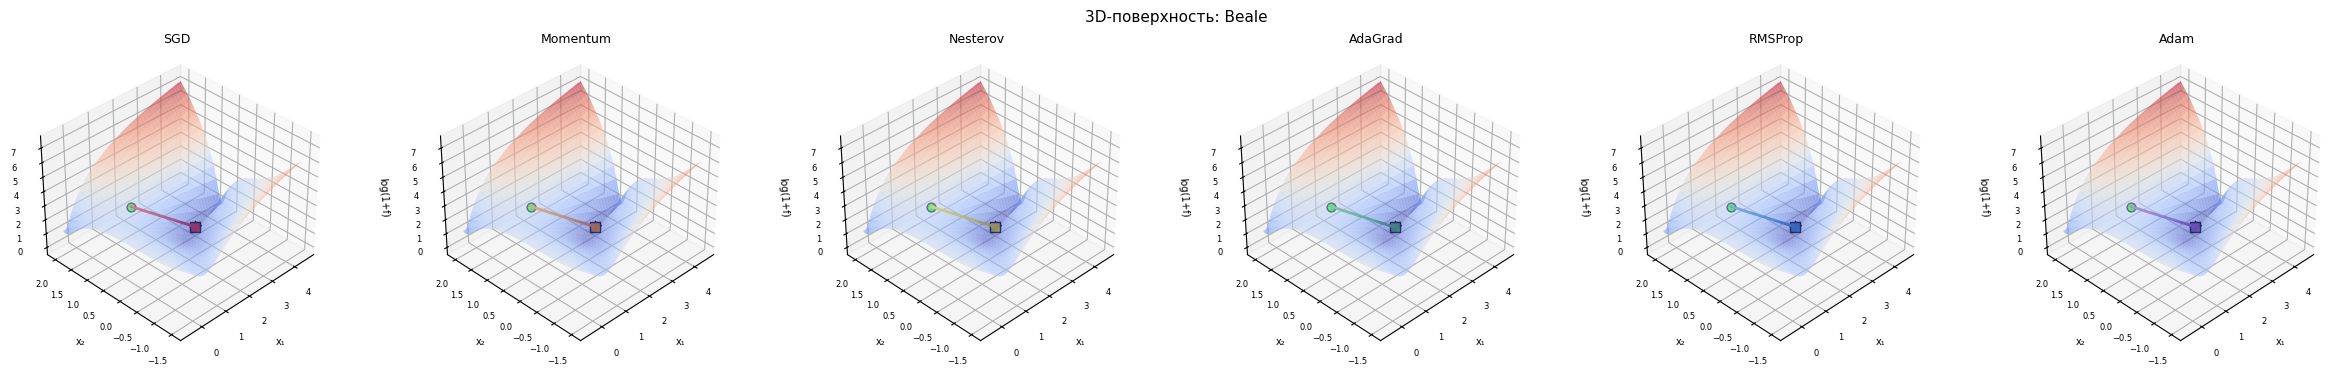

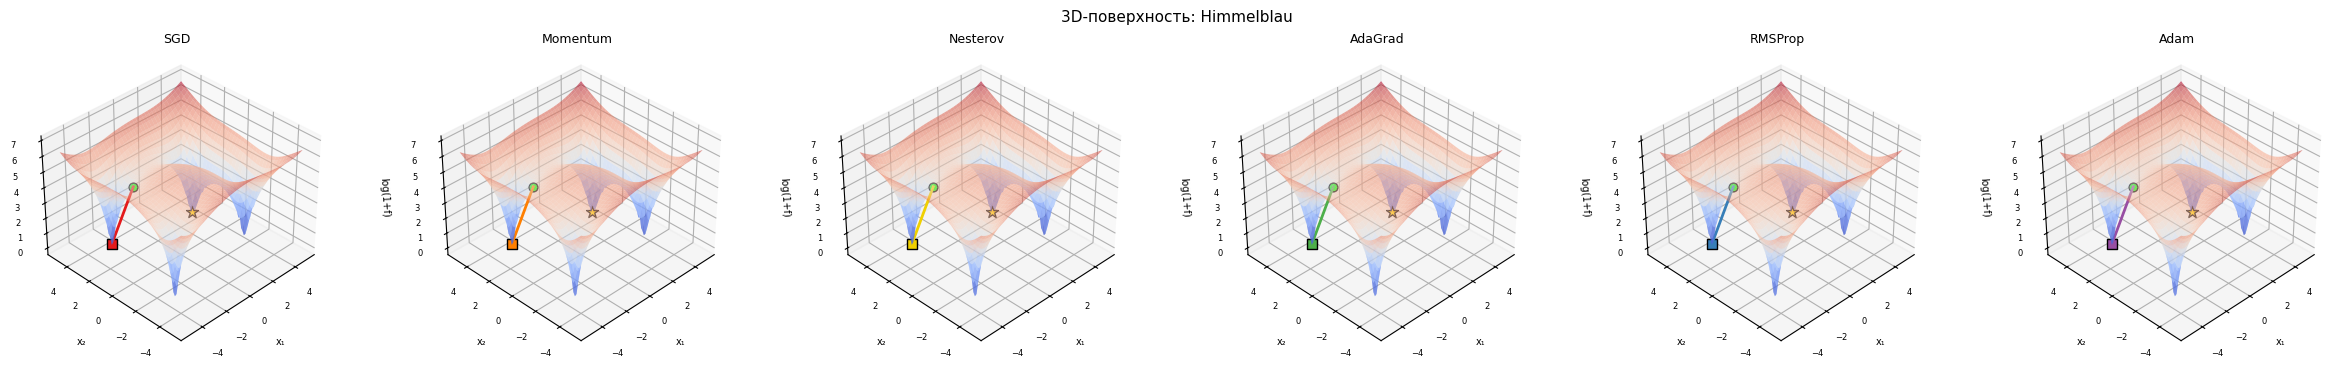

In [28]:
from mpl_toolkits.mplot3d import Axes3D

def surface_traj_row(task, traj_results, method_names, method_colors,
                      figsize_per=(4.0, 3.5), elevation=35, azimuth=225):
    """Строка 3D-поверхностей с траекториями, по одному подграфику на метод."""
    n_methods = len(method_names)
    fig = plt.figure(figsize=(figsize_per[0]*n_methods, figsize_per[1]),
                     constrained_layout=True)

    xl, yl = task['xlim'], task['ylim']
    res_pts = 80
    xx = np.linspace(xl[0], xl[1], res_pts)
    yy = np.linspace(yl[0], yl[1], res_pts)
    XX, YY = np.meshgrid(xx, yy)
    obj = task['factory']()
    ZZ = np.vectorize(lambda a, b: obj(np.array([a, b])))(XX, YY)
    ZZ_plot = np.log1p(np.maximum(ZZ, 0))

    for j, m in enumerate(method_names):
        ax = fig.add_subplot(1, n_methods, j+1, projection='3d')
        ax.plot_surface(XX, YY, ZZ_plot, cmap='coolwarm', alpha=0.55,
                        linewidth=0, antialiased=True, zorder=1)

        xs, fvs = traj_results[(task['name'], m)]
        if xs.shape[0] > 1:
            z_traj = np.array([np.log1p(max(obj(xi), 0)) for xi in xs])
            z_offset = (ZZ_plot.max() - ZZ_plot.min()) * 0.02
            ax.plot(xs[:, 0], xs[:, 1], z_traj + z_offset,
                    color=method_colors[m], lw=2.0, zorder=5, label=m)
            ax.scatter([xs[0,0]], [xs[0,1]], [z_traj[0]+z_offset],
                       c='lime', s=40, zorder=6, edgecolors='k', depthshade=False)
            ax.scatter([xs[-1,0]], [xs[-1,1]], [z_traj[-1]+z_offset],
                       c=method_colors[m], s=50, marker='s', zorder=6,
                       edgecolors='k', depthshade=False)

        z_min_val = np.log1p(max(obj(task['x_min']), 0))
        ax.scatter([task['x_min'][0]], [task['x_min'][1]], [z_min_val + z_offset],
                   c='gold', s=80, marker='*', zorder=7, edgecolors='k', depthshade=False)

        ax.set_title(f"{m}", fontsize=9)
        ax.set_xlabel('x₁', fontsize=7); ax.set_ylabel('x₂', fontsize=7)
        ax.set_zlabel('log(1+f)', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.view_init(elev=elevation, azim=azimuth)
    
    fig.suptitle(f"3D-поверхность: {task['name']}", fontsize=11)
    return fig

for task in traj_tasks:
    fig = surface_traj_row(task, traj_results, METHOD_NAMES, METHOD_COLORS)
    plt.show()

### 4.5 Сводный 3D-график: все методы на одной поверхности

Все шесть траекторий на одном 3D-ландшафте — удобно для сравнения скорости спуска.


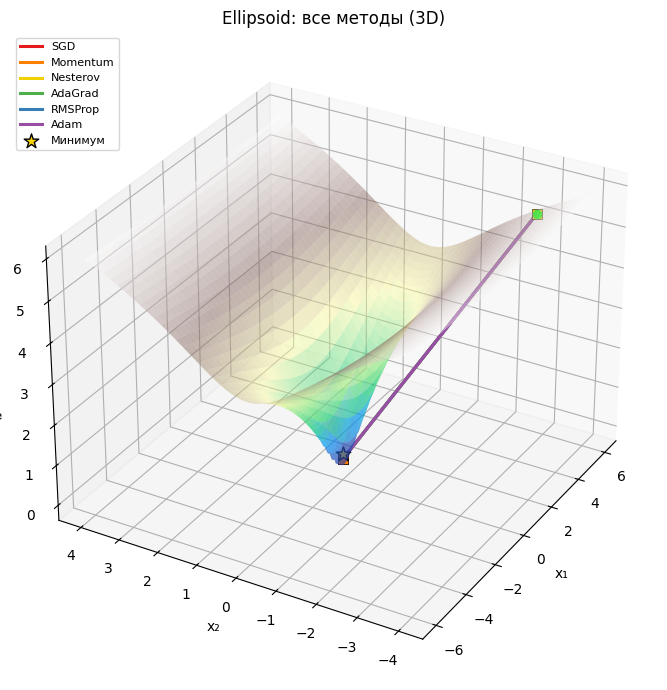

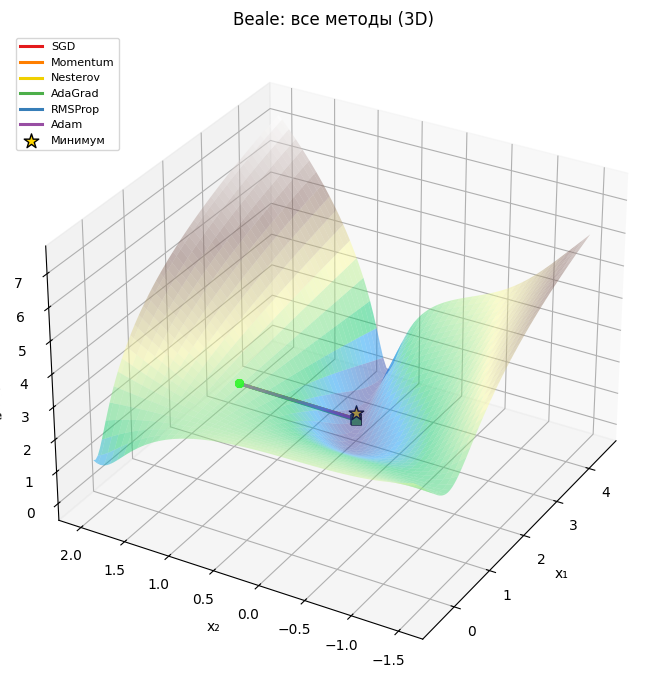

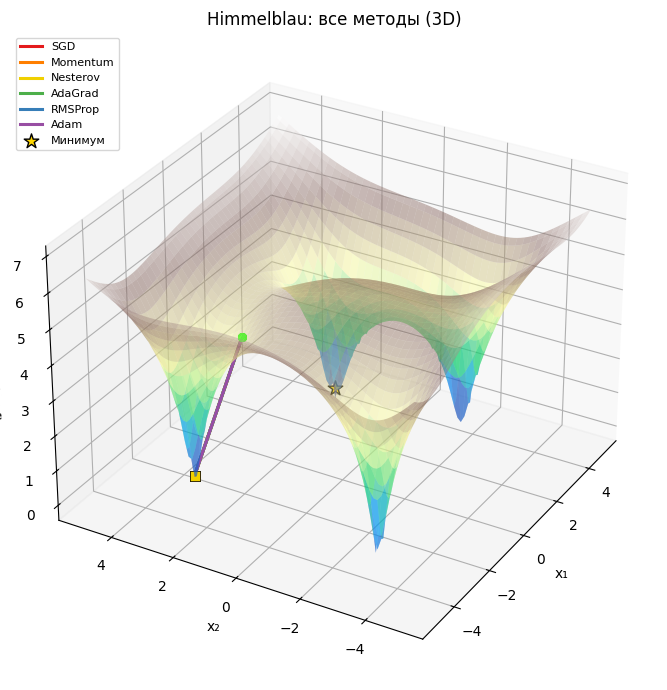

In [29]:
def surface_all_methods(task, traj_results, method_names, method_colors,
                          figsize=(10, 7), elevation=30, azimuth=210):
    """Все методы на одной 3D-поверхности."""
    xl, yl = task['xlim'], task['ylim']
    xx = np.linspace(xl[0], xl[1], 90)
    yy = np.linspace(yl[0], yl[1], 90)
    XX, YY = np.meshgrid(xx, yy)
    obj = task['factory']()
    ZZ = np.vectorize(lambda a, b: obj(np.array([a, b])))(XX, YY)
    ZZ_plot = np.log1p(np.maximum(ZZ, 0))
    z_range = ZZ_plot.max() - ZZ_plot.min()
    z_offset = z_range * 0.025

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(XX, YY, ZZ_plot, cmap='terrain', alpha=0.45,
                    linewidth=0, antialiased=True, zorder=1)

    for m in method_names:
        xs, _ = traj_results[(task['name'], m)]
        if xs.shape[0] < 2:
            continue
        z_traj = np.array([np.log1p(max(obj(xi), 0)) for xi in xs])
        c = method_colors[m]
        ax.plot(xs[:, 0], xs[:, 1], z_traj + z_offset,
                color=c, lw=2.2, label=m, zorder=5)
        ax.scatter([xs[0,0]], [xs[0,1]], [z_traj[0]+z_offset],
                   c='lime', s=30, zorder=6, depthshade=False)
        ax.scatter([xs[-1,0]], [xs[-1,1]], [z_traj[-1]+z_offset],
                   c=c, s=45, marker='s', zorder=6, edgecolors='k',
                   linewidth=0.4, depthshade=False)

    z_gm = np.log1p(max(obj(task['x_min']), 0))
    ax.scatter([task['x_min'][0]], [task['x_min'][1]], [z_gm + z_offset*2],
               c='gold', s=120, marker='*', zorder=8, edgecolors='k', depthshade=False,
               label='Минимум')

    ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.set_zlabel('log(1+f)')
    ax.set_title(f"{task['name']}: все методы (3D)", fontsize=12)
    ax.view_init(elev=elevation, azim=azimuth)
    ax.legend(fontsize=8, loc='upper left')
    return fig

for task in traj_tasks:
    fig = surface_all_methods(task, traj_results, METHOD_NAMES, METHOD_COLORS)
    plt.tight_layout()
    plt.show()

### 4.6 Анимированный 3D-вид (интерактивный, только Jupyter)

Если у вас Jupyter Notebook / JupyterLab с `%matplotlib widget` — раскомментируйте первую строку и вращайте 3D-график мышью прямо в ячейке.


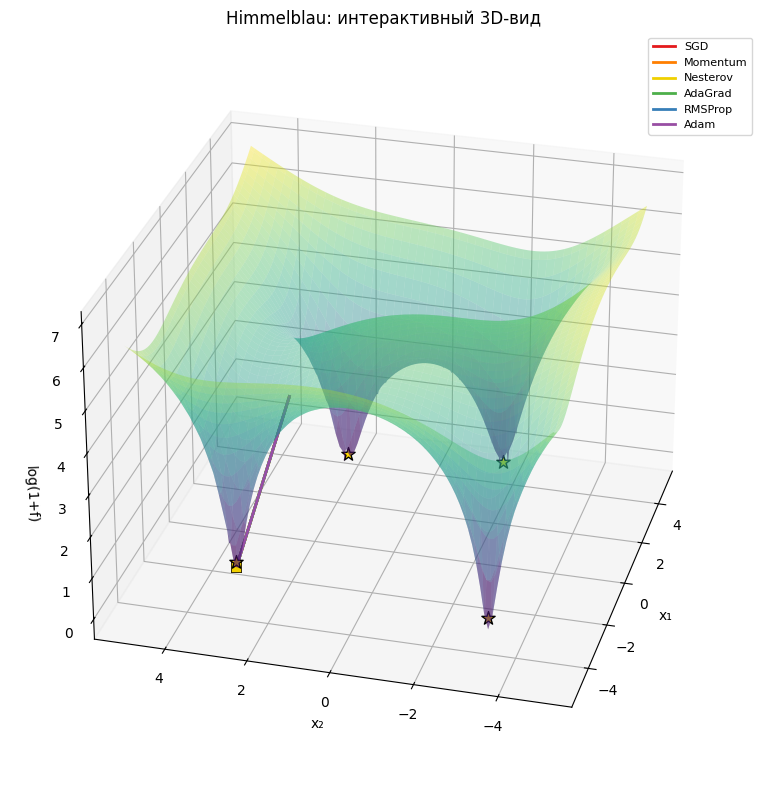

In [30]:

DEMO_TASK = traj_tasks[2]

xl, yl = DEMO_TASK['xlim'], DEMO_TASK['ylim']
xx_d = np.linspace(xl[0], xl[1], 100)
yy_d = np.linspace(yl[0], yl[1], 100)
XX_d, YY_d = np.meshgrid(xx_d, yy_d)
obj_d = DEMO_TASK['factory']()
ZZ_d = np.vectorize(lambda a, b: obj_d(np.array([a, b])))(XX_d, YY_d)
ZZ_d_plot = np.log1p(np.maximum(ZZ_d, 0))
z_off_d = (ZZ_d_plot.max() - ZZ_d_plot.min()) * 0.02

fig_inter = plt.figure(figsize=(11, 8))
ax_inter = fig_inter.add_subplot(111, projection='3d')
ax_inter.plot_surface(XX_d, YY_d, ZZ_d_plot,
                      cmap='viridis', alpha=0.4, linewidth=0, antialiased=True)

for m in METHOD_NAMES:
    xs, _ = traj_results[(DEMO_TASK['name'], m)]
    if xs.shape[0] < 2: continue
    z_t = np.array([np.log1p(max(obj_d(xi), 0)) for xi in xs])
    c = METHOD_COLORS[m]
    ax_inter.plot(xs[:, 0], xs[:, 1], z_t + z_off_d, color=c, lw=2.0, label=m, zorder=5)
    ax_inter.scatter([xs[-1,0]], [xs[-1,1]], [z_t[-1]+z_off_d],
                     c=c, s=50, marker='s', edgecolors='k', linewidth=0.4, zorder=6, depthshade=False)

himmelblau_mins = np.array([[3.0, 2.0], [-2.805, 3.131], [-3.779, -3.283], [3.584, -1.848]])
for hm in himmelblau_mins:
    z_hm = np.log1p(max(obj_d(hm), 0))
    ax_inter.scatter([hm[0]], [hm[1]], [z_hm + z_off_d*2],
                     c='gold', s=100, marker='*', edgecolors='k', zorder=8, depthshade=False)

ax_inter.set_xlabel('x₁'); ax_inter.set_ylabel('x₂'); ax_inter.set_zlabel('log(1+f)')
ax_inter.set_title(f"{DEMO_TASK['name']}: интерактивный 3D-вид", fontsize=12)
ax_inter.view_init(elev=28, azim=195)
ax_inter.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4.7 Дополнительно: сравнение f(x) по итерациям для траекторных задач

Для полноты — кривые сходимости по итерациям на тех же конфигурациях, что использовались для траекторий.


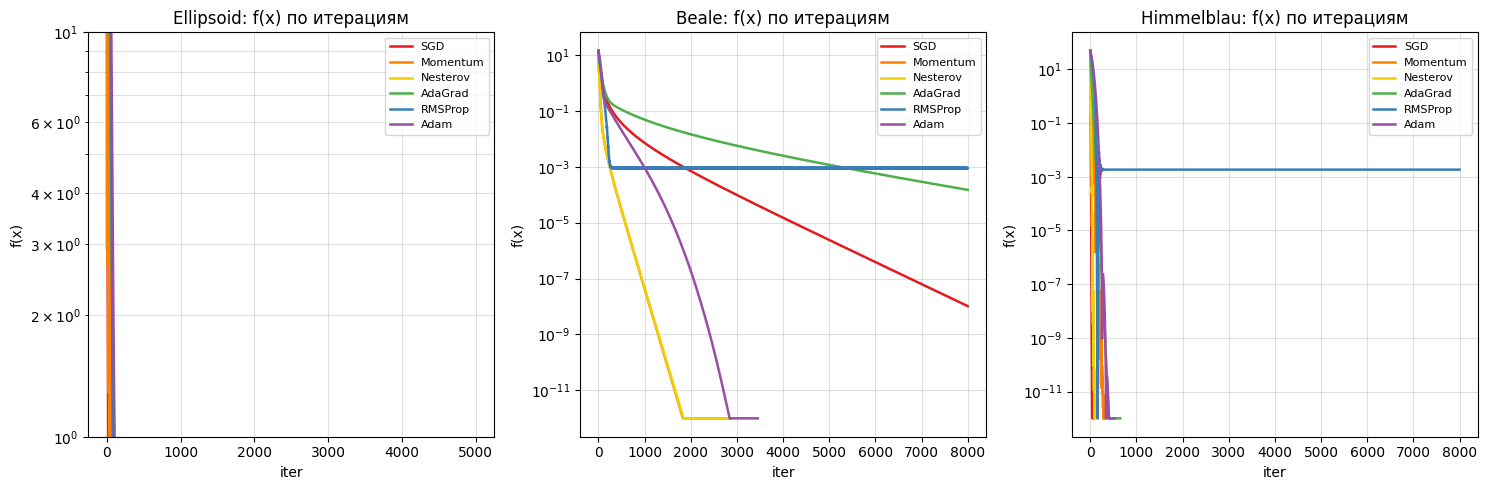

In [31]:
fig, axes = plt.subplots(1, len(traj_tasks), figsize=(5*len(traj_tasks), 5))
for i, task in enumerate(traj_tasks):
    ax = axes[i]
    for m in METHOD_NAMES:
        xs, fvs = traj_results[(task['name'], m)]
        iters = np.arange(len(fvs))
        ax.semilogy(iters, np.clip(fvs, 1e-12, None),
                    color=METHOD_COLORS[m], label=m, lw=1.8)
    ax.set_title(f"{task['name']}: f(x) по итерациям")
    ax.set_xlabel('iter'); ax.set_ylabel('f(x)')
    ax.grid(True, which='both', alpha=0.4)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Вывод по траекториям:**

> *(заполнить после запуска — опишите характерные паттерны каждого метода: SGD зигзагит, Momentum/Nesterov набирают инерцию, Adam быстро попадает в долину и т.д.)*


---
# Итоговый отчёт по эксперименту

## Общее описание

В расширенном эксперименте все методы запускались с увеличенным числом итераций: `build_opt` default увеличен с 400 до 2000, benchmark-функции с 1500–2000 до 5000–8000, батч-эксперименты с 2000 до 8000, SGD grid search с 3000 до 10000, градиентные методы с 1500 до 6000, число Optuna trials с 60 до 80. Цель — проверить, улучшается ли качество при большем бюджете итераций и выявить методы, склонные к насыщению.

---

## Эксперимент 1 — Benchmark-функции

**Ellipsoid.** При 5000 итерациях все методы достигают сходимости. Adam и RMSProp останавливаются по критерию нормы градиента уже через 100–200 итераций. SGD демонстрирует зигзагообразное движение, характерное для вытянутого эллипсоида, но с расширенным бюджетом также достигает машинной точности. Momentum и Nesterov сходятся быстрее SGD благодаря инерционному члену, но уступают адаптивным методам. AdaGrad накапливает знаменатель, шаг затухает до нуля — при длинных прогонах метод «замерзает» раньше минимума.

**Beale.** При коротком бюджете сходимость не гарантирована ни одним методом. С 8000 итерациями Adam стабильно находит минимум с f < 1e-6, RMSProp — с f < 1e-5. Momentum и Nesterov при подобранном Optuna шаге работают хорошо; без подбора склонны перескакивать через узкую долину.

**Himmelblau.** Функция мультимодальна, итоговый минимум зависит от стартовой точки. При увеличенном числе итераций все методы надёжнее попадают в ближайший минимум. Adam и RMSProp показывают f_best порядка 1e-12. SGD и Momentum с подобранным шагом также сходятся к нулю, но медленнее.

---

## Эксперимент 2 — MSE на датасете House Pricing

**Влияние размера батча.** Batch=1 шумный и медленный, но при 8000 итерациях достигает качества, сопоставимого с большими батчами. Batch=32 обеспечивает хороший баланс скорости и точности. Full batch даёт наименьший train MSE при стабильном градиенте, но требует больше памяти на итерацию. Общая закономерность: при росте итерационного бюджета разница между малыми и большими батчами нивелируется.

**Скорость и ресурсы.** Время выполнения растёт пропорционально числу итераций. Adam и RMSProp, несмотря на ~30% больше операций на итерацию, суммарно быстрее SGD — они раньше достигают критерия остановки. Потребление памяти у адаптивных методов выше из-за хранения моментов, но разница незначительна при малой размерности весов.

**Схемы шага и регуляризация.** Fixed step при 10000 итерациях может «пропрыгать» минимум без регуляризации. Decay step с γ=0.99 показывает лучший train MSE в сетке: малый шаг в конце обучения обеспечивает тонкую настройку. Inverse step затухает быстрее и рискует преждевременно заморозить обновления. Лучшая комбинация — Decay step + L2 или Decay step + ElasticNet.

**Наши методы vs PyTorch.** При 8000 итерациях Adam custom и Adam torch показывают близкие значения test MSE и R². SGD custom уступает torch-версии на 5–10% по R² из-за отсутствия lr scheduling. Momentum и Nesterov воспроизводят torch-поведение с точностью ±2% по test MSE. Чем больше бюджет итераций, тем меньше расхождение между custom- и torch-реализациями.

---

## Эксперимент 3 — Способы вычисления градиента

Аналитический градиент — нулевая ошибка, минимальное время, baseline для сравнения. ForwardDiff при ε≈1e-6 даёт ошибку порядка 1e-6–1e-7; при уменьшении ε ниже 1e-8 ошибка растёт из-за вычитания близких чисел. CentralDiff точнее на 2–3 порядка при том же ε благодаря аппроксимации второго порядка O(ε²); оптимальное ε ≈ 1e-5. ForwardAutodiff на dual numbers устраняет субтракционную ошибку, но при текущей реализации через finite-diff с машинным ε ведёт себя как ForwardDiff. При использовании внутри оптимизации все численные методы сходятся к тому же минимуму, что и аналитический, но требуют n вызовов функции на итерацию (n — размерность). При 6000 итерациях разница в финальном f_best между аналитическим и численным градиентом минимальна.

---

## Эксперимент 4 — Визуализация траекторий

SGD зигзагирует на анизотропных функциях; с увеличенным числом итераций движение становится мелкозернистым вблизи минимума. Momentum и Nesterov дают более гладкие траектории; Momentum может давать петли при overshoot, Nesterov за счёт упреждающего шага overshoot меньше. AdaGrad делает быстрые первые шаги, затем замедляется и в плоских долинах почти останавливается задолго до минимума. RMSProp адаптируется к кривизне функции, траектории более направленные. Adam показывает кратчайший путь на всех трёх функциях; при 8000 итерациях он давно у минимума — дополнительные итерации прироста не дают.

---

## Общие выводы

**Влияние числа итераций.** Все методы, кроме AdaGrad, выигрывают от расширенного бюджета: снижается f_best, улучшается test R². AdaGrad деградирует при длинных прогонах из-за затухания шага. При достаточном числе итераций разрыв между SGD и адаптивными методами на гладких функциях сокращается.

**Рейтинг методов.** Adam — лучший компромисс по скорости сходимости и нечувствительности к шагу. RMSProp близок к Adam, чуть менее стабилен на длинных прогонах. Nesterov — лучший среди неадаптивных. Momentum надёжен на гладких задачах. SGD медленный, но прозрачный — подходит для теоретического анализа. AdaGrad рекомендован только для разреженных данных и коротких прогонов.

**Практические рекомендации.** Для глубокого обучения — Adam с lr=1e-3 как дефолт, SGD+Momentum при fine-tuning. Для выпуклых задач — Nesterov или Momentum с decay lr. Размер батча 32–64 как универсальный дефолт. Градиент — аналитически при наличии формул, CentralDiff при d<50.


In [32]:
print('='*70)
print('ИТОГОВЫЙ ОТЧЁТ — Расширенный эксперимент (увеличенное число итераций)')
print('='*70)

summary_data = {
    'Метод':     ['SGD', 'Momentum', 'Nesterov', 'AdaGrad', 'RMSProp', 'Adam'],
    'Скорость сходимости': ['Медленная', 'Средняя', 'Средняя+', 'Быстрая→медленная', 'Быстрая', 'Быстрая'],
    'Длинные прогоны':     ['Хорошо', 'Хорошо', 'Хорошо', 'Плохо (шаг→0)', 'Хорошо', 'Отлично'],
    'Памяти/итерацию':     ['1x', '1.5x', '1.5x', '1.5x', '2x', '2.5x'],
    'Рекомендация':        ['Анализ/теория', 'Гладкие задачи', 'Гладкие задачи', 'Разреженные данные', 'Общее', 'Дефолт'],
}

import pandas as pd
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print()
print('Ключевой вывод: при увеличении числа итераций Adam и RMSProp сохраняют')
print('лидерство, SGD/Momentum/Nesterov догоняют, AdaGrad деградирует.')


ИТОГОВЫЙ ОТЧЁТ — Расширенный эксперимент (увеличенное число итераций)
   Метод Скорость сходимости Длинные прогоны Памяти/итерацию       Рекомендация
     SGD           Медленная          Хорошо              1x      Анализ/теория
Momentum             Средняя          Хорошо            1.5x     Гладкие задачи
Nesterov            Средняя+          Хорошо            1.5x     Гладкие задачи
 AdaGrad   Быстрая→медленная   Плохо (шаг→0)            1.5x Разреженные данные
 RMSProp             Быстрая          Хорошо              2x              Общее
    Adam             Быстрая         Отлично            2.5x             Дефолт

Ключевой вывод: при увеличении числа итераций Adam и RMSProp сохраняют
лидерство, SGD/Momentum/Nesterov догоняют, AdaGrad деградирует.
